In [1]:
import numpy as np
import cv2 
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms,models
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [3]:
main_path = "/kaggle/input/pets-facial-expression-dataset/Master Folder/"
train_path = main_path+"train/"
val_path = main_path+"valid/"
img_folder = ImageFolder(root=train_path)


# Class Counts and Different Image Sizes

In [4]:
class_counts = {}
image_sizes = {}
for img, img_cls in img_folder:
    if img.size not in image_sizes:
        image_sizes[img.size] = 0
    image_sizes[img.size] += 1
    
    if img_cls not in class_counts:
        class_counts[img_cls] = 0

    class_counts[img_cls] += 1

print(class_counts)
print(image_sizes)

{0: 250, 1: 250, 2: 250, 3: 250}
{(224, 224): 633, (179, 179): 367}


# Augmentations & Transforms

In [5]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

data_transforms = {
    'train':
    transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.01),
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ]),
    'validation':
    transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        normalize
    ]),
}

# Dataset & Dataloader

In [6]:
class PetDataset(Dataset):
    def __init__(self,root_dir,transform=None):
        self.dataset = ImageFolder(root = root_dir,transform=transform)
        self.transform = transform
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self,index):
        image , label  = self.dataset[index]
        samples = {'image':image,'label':label}
        return samples
        

In [7]:
train_dataset = PetDataset(train_path,data_transforms['train'])
val_dataset = PetDataset(val_path,data_transforms['validation'])

In [8]:
train_loader = DataLoader(train_dataset,batch_size = 16,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size = 16,shuffle=False)

Feature batch shape: torch.Size([16, 3, 224, 224])
Labels batch shape: torch.Size([16])


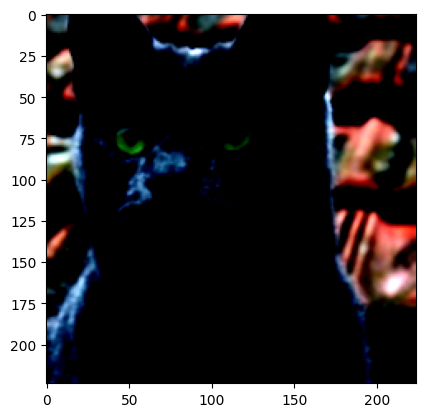

Label: 2


In [9]:
# Display image and label.
batch = next(iter(train_loader))
print(f"Feature batch shape: {batch['image'].size()}")
print(f"Labels batch shape: {batch['label'].size()}")
img = batch['image'][3].squeeze()
label = batch['label'][3]
plt.imshow(img.permute(1, 2, 0))
plt.show()
print(f"Label: {label}")

# Model

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [12]:
import torch
import torch.nn as nn

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride, padding=1, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu(self.bn1(self.depthwise(x)))
        x = self.relu(self.bn2(self.pointwise(x)))
        return x

class MobileNet(nn.Module):
    def __init__(self, num_classes=4):
        super(MobileNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            DepthwiseSeparableConv(32, 64),
            DepthwiseSeparableConv(64, 128, stride=2),
            DepthwiseSeparableConv(128, 128),
            DepthwiseSeparableConv(128, 256, stride=2),
            DepthwiseSeparableConv(256, 256),
            DepthwiseSeparableConv(256, 512, stride=2),

            *[DepthwiseSeparableConv(512, 512) for _ in range(5)],

            DepthwiseSeparableConv(512, 1024, stride=2),
            DepthwiseSeparableConv(1024, 1024),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x



In [13]:
# Create MobileNet Model
model = MobileNet(num_classes=4)
print(model)
model.to(device)

MobileNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): DepthwiseSeparableConv(
      (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (4): DepthwiseSeparableConv(
      (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
      (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

MobileNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): DepthwiseSeparableConv(
      (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (4): DepthwiseSeparableConv(
      (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
      (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

# Sample Batch

In [14]:
batch = next(iter(train_loader))
model(batch['image'].to(device)).shape

torch.Size([16, 4])

In [15]:
test_output = model(batch['image'].to(device))
print(test_output.argmax(dim=1))

tensor([3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 1, 3], device='cuda:0')


# Loss and Optimizer

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training Val Loop

In [17]:
def train_loop(model,loader,epoch):
    train_pred = []
    train_labels = []
    train_loss = 0
    total_samples = 0
    for i,data in enumerate(loader):
        optimizer.zero_grad()
        image = data['image'].to(device)
        label = data['label'].to(device)
        
        outputs = model(image)
        loss = criterion(outputs,label)
        
        loss.backward()
        optimizer.step()
        
        train_loss+= loss.item()
        train_pred.append(torch.argmax(outputs,dim = 1).cpu().detach().numpy())
        train_labels.append(label.cpu().detach().numpy())
        total_samples += data['image'].size(0) 
        
    print("Train Epoch: ",epoch,"| Loss: ",(train_loss/total_samples))
        
    return np.concatenate(train_pred).ravel(), np.concatenate(train_labels).ravel(),(train_loss/total_samples)


def val_loop(model,loader,epoch):
    val_pred = []
    val_labels = []
    val_loss = 0
    total_samples = 0
    with torch.no_grad():
        for i,data in enumerate(loader):
            optimizer.zero_grad()
            image = data['image'].to(device)
            label = data['label'].to(device)
            outputs = model(image)
            loss = criterion(outputs,label)
            val_loss+= loss.item()
            val_pred.append(torch.argmax(outputs,dim = 1).cpu().detach().numpy())
            val_labels.append(label.cpu().detach().numpy())
            total_samples += data['image'].size(0) 
            
        print("Val Epoch: ",epoch,"| Loss: ",(val_loss/total_samples))
        
        return np.concatenate(val_pred).ravel(), np.concatenate(val_labels).ravel(),(val_loss/total_samples)
        
        

In [ ]:
# import torch.optim.lr_scheduler as lr_scheduler


# scheduler = lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)  # Reduce LR every 1 epochs by a factor of 0.5

# num_epochs = 10
# train_preds = []
# train_labels = []
# train_loss_list = []

# val_preds = []
# val_labels = []
# val_loss_list = []

# for i in range(num_epochs):
#     current_lr = optimizer.param_groups[0]['lr']
#     print("Epoch: ", i, "| Learning Rate : ", current_lr)
    
#     model.train()
#     train_preds, train_labels, train_loss = train_val(model, train_loader, i + 1, "train")
#     train_loss_list.append(train_loss)
#     print("Train Accuracy: ", accuracy_score(train_labels, train_preds))
    
#     model.eval()
#     val_preds, val_labels, val_loss = train_val(model, val_loader, i + 1, "val")
#     val_loss_list.append(val_loss)
#     print("Val Accuracy: ", accuracy_score(val_labels, val_preds))
    
#     # Update the learning rate at the end of each epoch
#     scheduler.step()


In [18]:
import os

# Directory to save models
save_dir = "/kaggle/working/saved_models"
os.makedirs(save_dir, exist_ok=True)

num_epochs = 100
patience = 10  # Number of epochs to wait before reducing the learning rate
learning_rate_decay_facor = 0.5
best_val_accuracy = 0
epochs_since_improvement = 0

train_preds = []
train_labels = []
train_loss_list = []

val_preds = []
val_labels = []
val_loss_list = []

for i in range(num_epochs):
    current_lr = optimizer.param_groups[0]['lr']
    print("Epoch: ", i, "| Learning Rate : ", current_lr)
    
    # Train phase
    model.train()
    train_preds, train_labels, train_loss = train_loop(model, train_loader, i + 1)
    train_loss_list.append(train_loss)
    print("Train Accuracy: ", accuracy_score(train_labels, train_preds))
    
    # Validation phase
    model.eval()
    val_preds, val_labels, val_loss = val_loop(model, val_loader, i + 1)
    val_loss_list.append(val_loss)
    val_accuracy = accuracy_score(val_labels, val_preds)
    print("Val Accuracy: ", val_accuracy)
    
    # Check for improvement
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        epochs_since_improvement = 0
        
        # Save the model
        save_path = os.path.join(save_dir, f"best_model_epoch_{i + 1}.pth")
        torch.save(model.state_dict(), save_path)
        print(f"New best model saved to {save_path}.")
    else:
        epochs_since_improvement += 1

    # Reduce the learning rate if no improvement for 'patience' epochs
    if epochs_since_improvement >= patience:
        current_lr = current_lr * learning_rate_decay_facor
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
        print(f"No improvement for {patience} epochs. Reducing learning rate to {current_lr}.")
        epochs_since_improvement = 0


Epoch:  0 | Learning Rate :  0.0001
Train Epoch:  1 | Loss:  0.08690375483036042
Train Accuracy:  0.282
Val Epoch:  1 | Loss:  0.12276890873908997
Val Accuracy:  0.3055555555555556
New best model saved to /kaggle/working/saved_models/best_model_epoch_1.pth.
Epoch:  1 | Learning Rate :  0.0001
Train Epoch:  2 | Loss:  0.08679127776622772
Train Accuracy:  0.286
Val Epoch:  2 | Loss:  0.12240703569518195
Val Accuracy:  0.2777777777777778
Epoch:  2 | Learning Rate :  0.0001
Train Epoch:  3 | Loss:  0.08588341414928437
Train Accuracy:  0.33
Val Epoch:  3 | Loss:  0.10849661959542169
Val Accuracy:  0.3055555555555556
Epoch:  3 | Learning Rate :  0.0001
Train Epoch:  4 | Loss:  0.08604619336128234
Train Accuracy:  0.316
Val Epoch:  4 | Loss:  0.11639383435249329
Val Accuracy:  0.3333333333333333
New best model saved to /kaggle/working/saved_models/best_model_epoch_4.pth.
Epoch:  4 | Learning Rate :  0.0001
Train Epoch:  5 | Loss:  0.08522654879093171
Train Accuracy:  0.344
Val Epoch:  5 | Los

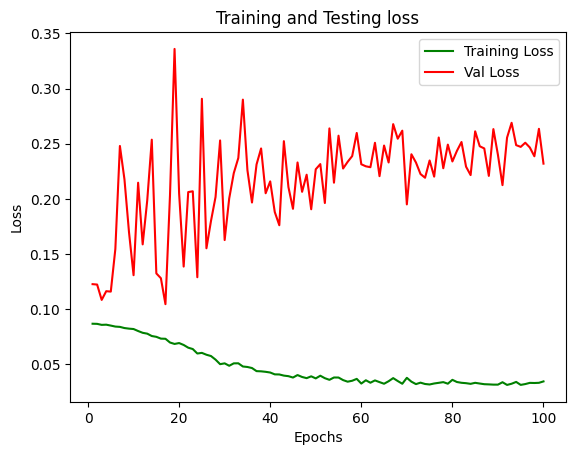

In [19]:
plt.plot([i+1 for i in range(num_epochs)],train_loss_list,'g',label='Training Loss')
plt.plot([i+1 for i in range(num_epochs)],val_loss_list,'r',label='Val Loss')
plt.title('Training and Testing loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
total_samples = 0

# # Iterate through the DataLoader and count samples
for batch in train_loader:
    total_samples += batch['image'].size(0)  # batch[0] contains the input data (images)

print("Sample train = ",total_samples)
total_samples = 0
for batch in val_loader:
    total_samples += batch['image'].size(0)  # batch[0] contains the input data (images)
print("Sample val = ", total_samples)

Sample train =  1000
Sample val =  36
